# Deep Learning - 2026

## Dependencies

In [18]:
import os
import stat
from pathlib import Path
import numpy as np
import tensorflow as tf

## Auxiliary functions /code

In [25]:
def count_n_images_iterator(this_iterator, name, what='images'):
    """
    Function to count the number of items (images/batches) in the dataset that
    is an iterator. Does not return. Prints a string.

    Input:
        this_iterator: tf.data.Dataset
            Iterator containing the data. TensorFlow Dataset.
        name: str
            Name of the dataset. Should be 'train','test','validation'
        what: str
            Specifies if we are dealing with single images or batches. Should
            be 'images' or 'batches'.

    Output:
        None
    """

    count_items = 0
    for item, label in this_iterator:
        count_items += 1

    print(f'The {name} dataset has {count_items} {what}.')

## Load Data

### Download from Kaggle

In [19]:
import os
from pathlib import Path

# Point Kaggle API to the kaggle.json in the project root
os.environ["KAGGLE_CONFIG_DIR"] = str(Path.cwd())

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

if not any(DATA_DIR.iterdir()):   # skip if already downloaded
    os.system(f"kaggle datasets download -d <username>/<dataset-name> -p {DATA_DIR} --unzip")


### About Dataset 
(Extract from Kaggle @ https://www.kaggle.com/datasets/airbusgeo/airbus-wind-turbines-patches/data)

#### Context

Wind turbines make electricity from wind. Wind turns the propeller-like blades of a turbine around a rotor, which spins a generator, which creates electricity. Generating electricity from wind rather than from gas helps fight global warming. More and more states and private companies are investing in renewable energies and building huge wind turbines plants. Knowing where this wind turbines are located is essential and could help in energy production forecast. Deep Learning could help identify wind turbines on satellite image.

#### Content

This is very simple dataset which objective is to build a classifier of satellite images extract with or without wind turbines. Extracts of 128 x 128 pixels with wind turbines are located in a folder called targets ; extracts without wind turbines are located in a folder called background. Images are extracted from satellite acquisitions from the Airbus SPOT6 and SPOT7 satellites which resolution is 1.5 meters per pixel. So extracts of 128 x 128 pixels represents roughly 192 meters on the ground which is compatible with the typical size of a wind turbine.

### Load from directory

In [20]:
# Load data from 
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

for root, dirs, files in os.walk(DATA_DIR):
    dirs.sort()
    level = root.replace(str(DATA_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    if level >= 2:          # don't recurse too deep
        dirs.clear()

data/  (0 files)
  train/  (0 files)
    background/  (202565 files)
    target/  (154942 files)
  val/  (0 files)
    background/  (40513 files)
    target/  (30991 files)


The dataset comes with a default split through different directories. It is necessary to pool from both and then split manually to create test, train and validation sets.

### Train, Test, Validation split

In [21]:
# The two class folders inside each split directory
classes = ['background', 'target']  # label 0 = background, label 1 = target

# --- Step 1: Collect all image paths and their labels ---
# We pool train/ and val/ together so we can re-split on our own terms
all_files  = []   # will hold the path to each image file
all_labels = []   # will hold the class index (0 or 1) for each image

for split in ['train', 'val']:
    for label_idx, cls in enumerate(classes):
        class_dir = DATA_DIR / split / cls          # e.g. data/train/background
        for f in class_dir.iterdir():               # iterate over every file in that folder
            all_files.append(str(f))
            all_labels.append(label_idx)

# Convert lists to numpy arrays so we can index them easily later
all_files  = np.array(all_files)
all_labels = np.array(all_labels)

print(f"Total images collected: {len(all_files)}")

# --- Step 2: Shuffle ---
# We shuffle so that train/test/val each get a random mix of images,
# not all images from one folder grouped together.
rng = np.random.default_rng(seed=42)        # seed=42 makes the shuffle reproducible
idx = rng.permutation(len(all_files))       # a random ordering of indices
all_files  = all_files[idx]
all_labels = all_labels[idx]

# --- Step 3: Split into three equal parts (~1/3 each) ---
n  = len(all_files)
n1 = n // 3          # end of train slice
n2 = 2 * n // 3      # end of test slice  (rest goes to val)

train_files, train_labels = all_files[:n1],   all_labels[:n1]
test_files,  test_labels  = all_files[n1:n2],  all_labels[n1:n2]
val_files,   val_labels   = all_files[n2:],    all_labels[n2:]

print(f"The train_files object has {len(train_files)} images.")
print(f"The test_files object has {len(test_files)} images.")
print(f"The validation_files object has {len(val_files)} images.")


Total images collected: 429011
The train_files object has 143003 images.
The test_files object has 143004 images.
The validation_files object has 143004 images.


### Make tensorflow datasets

In [28]:
IMG_SIZE = (128, 128) # images are already 128x128, but we can still use this to ensure the shape is correct
BATCH_SIZE = 32

def make_dataset(files, labels, shuffle=False):
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=42)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = make_dataset(train_files, train_labels, shuffle=True)
test_dataset  = make_dataset(test_files,  test_labels)
val_dataset   = make_dataset(val_files,   val_labels)

print(f"The train dataset has {len(train_files)} images.")
print(f"The test dataset has {len(test_files)} images.")
print(f"The validation dataset has {len(val_files)} images.")

The train dataset has 143003 images.
The test dataset has 143004 images.
The validation dataset has 143004 images.


## Explore the Data

In [23]:
print("Class distribution across splits:\n")
for name, files, labels in [("Train", train_files, train_labels),
                             ("Test",  test_files,  test_labels),
                             ("Val",   val_files,   val_labels)]:
    n_bg  = (labels == 0).sum()
    n_tgt = (labels == 1).sum()
    total = len(labels)
    print(f"{name:6} | total: {total:6} | background: {n_bg:6} ({n_bg/total:.1%}) | target: {n_tgt:6} ({n_tgt/total:.1%})")


Class distribution across splits:

Train  | total: 143003 | background:  81073 (56.7%) | target:  61930 (43.3%)
Test   | total: 143004 | background:  81205 (56.8%) | target:  61799 (43.2%)
Val    | total: 143004 | background:  80800 (56.5%) | target:  62204 (43.5%)


There's a moderate class imbalance which shouldn't be critical for the purpose of this study (~57% vs ~43%). This is expected since the shuffle was applied before splitting, ensuring each split mirrors the original distribution.

The imbalance is consistent across the three datasets, so corrective measure shouldn't be required - it will depend on the performance of the model.

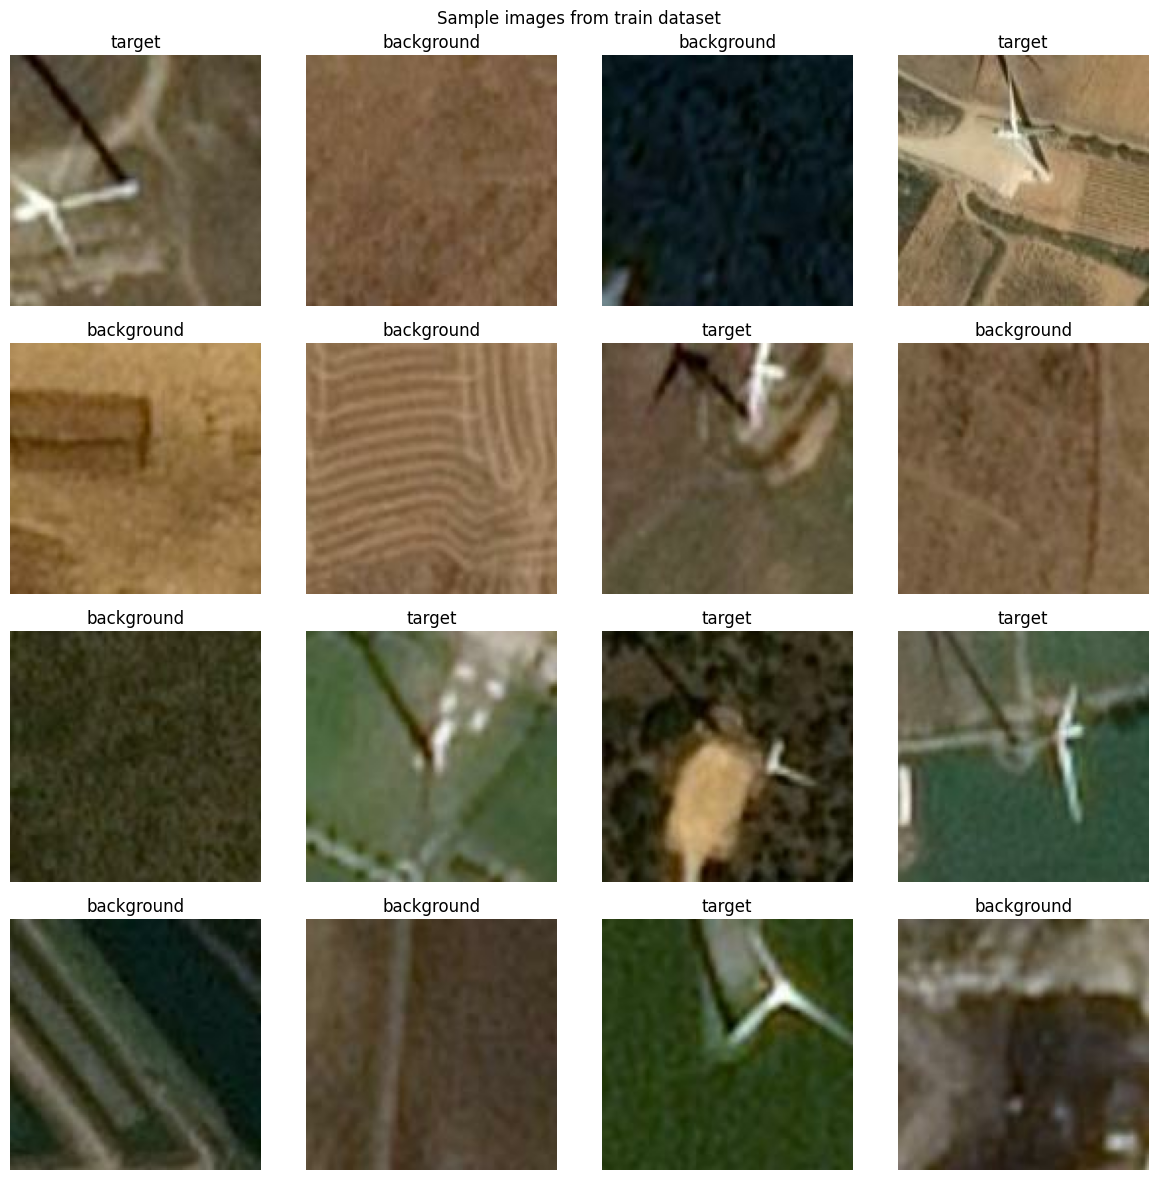

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

col = 0
for images, labels in train_dataset:
    for img, label in zip(images, labels):
        if col >= 16:
            break
        axes[col].imshow(img.numpy())
        axes[col].set_title("target" if label.numpy() == 1 else "background")
        axes[col].axis('off')
        col += 1
    if col >= 16:
        break

plt.suptitle("Sample images from train dataset")
plt.tight_layout()
plt.show()


The dataset contains images 128x128 - they are all the same size, which can be confirmed by reading the "About Dataset" section from Kaggle. This was also ensured when making the tensorflow dataset objects.

The dataset has color, therefore 3 channels.

The dataset is relatively big, for the porpuse of rapid iteration a sub set of it is going to be selected.

## Transform Data

### Create sub-sample

In [29]:
sub_ds_train = train_dataset.take(5000)
sub_ds_test  = test_dataset.take(200)
sub_ds_val   = val_dataset.take(500)

count_n_images_iterator(sub_ds_train, 'train'),
count_n_images_iterator(sub_ds_test, 'test'),
count_n_images_iterator(sub_ds_val, 'validation')

The train dataset has 5000 images.
The test dataset has 200 images.
The validation dataset has 500 images.


### Normalize

In [30]:
def normalize_image(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

normalize_ds_train = sub_ds_train.map(normalize_image)
normalize_ds_test  = sub_ds_test.map(normalize_image)
normalize_ds_val   = sub_ds_val.map(normalize_image)


### Resize

In [31]:
# Images are already 128x128 — no resizing needed
resized_ds_train = normalize_ds_train
resized_ds_test  = normalize_ds_test
resized_ds_val   = normalize_ds_val


In [32]:
BATCH_SIZE = 256

resized_ds_train = resized_ds_train.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
resized_ds_test  = resized_ds_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
resized_ds_val   = resized_ds_val.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

count_n_images_iterator(resized_ds_train, 'train', 'batches')
count_n_images_iterator(resized_ds_test,  'test',  'batches')
count_n_images_iterator(resized_ds_val,   'validation', 'batches')


The train dataset has 20 batches.
The test dataset has 1 batches.
The validation dataset has 2 batches.
